# Airbnb Modeling

In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

In [5]:

linear_model_df = pd.read_csv('../data/processed/airbnb_linear_features_df.csv')

print(linear_model_df.shape)
linear_model_df.head()

(47928, 11)


,attraction_count_3km,distance_to_city_center,neighbourhood_group_Manhattan,night_crime_ratio_2km,felony_count_2km,misdemeanor_ratio_2km,station_count_1km,log_distance_to_nearest_station,room_type_Private room,room_type_Shared room,log_price
0,2,12.337898,0,0.242109,2899,0.515096,4,0.382104,1,0,5.010635
1,19,0.508366,1,0.205736,10974,0.540041,18,0.090684,0,0,5.420535
2,1,6.757240,1,0.206138,8335,0.578210,4,0.287966,1,0,5.017280
3,2,8.387034,0,0.221725,5417,0.524755,7,0.347774,0,0,4.499810
4,2,5.701496,1,0.205123,7054,0.571406,6,0.182477,0,0,4.394449


In [6]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
import pandas as pd

# X, y 준비
X = linear_model_df.drop(columns=['log_price'])
y = linear_model_df['log_price']

# 5-fold cross validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 평가 지표
scoring = {
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}

# 비교할 회귀 모델들
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=42
    )
}

cv_results = []

for model_name, model in models.items():
    scores = cross_validate(
        model,
        X,
        y,
        cv=kf,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        'model': model_name,
        'CV_RMSE_mean': -scores['test_rmse'].mean(),
        'CV_RMSE_std': scores['test_rmse'].std(),
        'CV_MAE_mean': -scores['test_mae'].mean(),
        'CV_MAE_std': scores['test_mae'].std(),
        'CV_R2_mean': scores['test_r2'].mean(),
        'CV_R2_std': scores['test_r2'].std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values('CV_R2_mean', ascending=False)
display(cv_results_df)


,model,CV_RMSE_mean,CV_RMSE_std,CV_MAE_mean,CV_MAE_std,CV_R2_mean,CV_R2_std
3,XGBoost,0.422787,0.003310,0.320825,0.001696,0.573517,0.002963
2,Gradient Boosting,0.427098,0.003403,0.323952,0.001957,0.564779,0.002550
0,Linear Regression,0.437774,0.003679,0.332224,0.001807,0.542752,0.002999
1,Ridge,0.437777,0.003687,0.332229,0.001807,0.542746,0.003025


In [15]:
# Linear Regression 전체 데이터로 다시 학습
lr_final_model = LinearRegression()
lr_final_model.fit(X, y)

lr_coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lr_final_model.coef_,
    'abs_coefficient': abs(lr_final_model.coef_)
}).sort_values('abs_coefficient', ascending=False)

display(lr_coef_df)


,feature,coefficient,abs_coefficient
3,night_crime_ratio_2km,-1.575879,1.575879
9,room_type_Shared room,-1.064863,1.064863
8,room_type_Private room,-0.699384,0.699384
5,misdemeanor_ratio_2km,-0.092203,0.092203
7,log_distance_to_nearest_station,0.043275,0.043275
1,distance_to_city_center,-0.023254,0.023254
0,attraction_count_3km,0.018236,0.018236
6,station_count_1km,0.008018,0.008018
2,neighbourhood_group_Manhattan,0.006763,0.006763
4,felony_count_2km,-0.000017,0.000017


In [16]:
ridge_final_model = Ridge(alpha=1.0)
ridge_final_model.fit(X, y)

ridge_coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': ridge_final_model.coef_,
    'abs_coefficient': abs(ridge_final_model.coef_)
}).sort_values('abs_coefficient', ascending=False)

display(ridge_coef_df)


,feature,coefficient,abs_coefficient
3,night_crime_ratio_2km,-1.516604,1.516604
9,room_type_Shared room,-1.064180,1.064180
8,room_type_Private room,-0.699551,0.699551
5,misdemeanor_ratio_2km,-0.078044,0.078044
7,log_distance_to_nearest_station,0.043607,0.043607
1,distance_to_city_center,-0.023228,0.023228
0,attraction_count_3km,0.018289,0.018289
6,station_count_1km,0.008029,0.008029
2,neighbourhood_group_Manhattan,0.007315,0.007315
4,felony_count_2km,-0.000017,0.000017


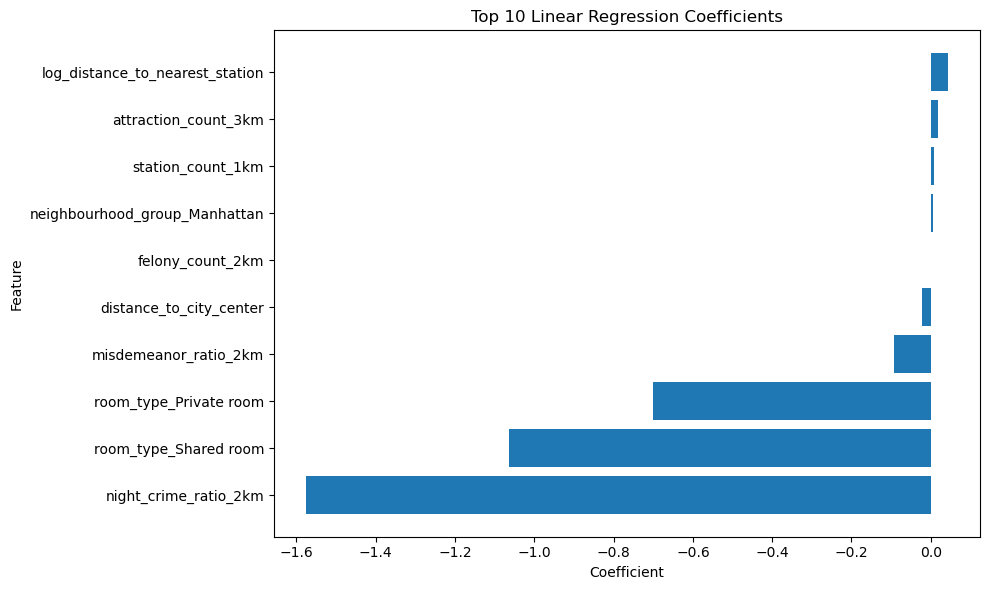

In [17]:
import matplotlib.pyplot as plt

top_n = 10
top_lr_coef_df = lr_coef_df.head(top_n).sort_values('coefficient')

plt.figure(figsize=(10, 6))
plt.barh(top_lr_coef_df['feature'], top_lr_coef_df['coefficient'])
plt.title(f'Top {top_n} Linear Regression Coefficients')
plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


## tree_df

In [7]:
import pandas as pd
import numpy as np

from sklearn.model_selection import KFold, cross_validate
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor


In [8]:
tree_model_df = pd.read_csv('../data/processed/airbnb_tree_features_df.csv')

print(tree_model_df.shape)
tree_model_df.head()


(47928, 38)


,neighbourhood_group,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,attraction_count_2km,attraction_count_3km,...,felony_ratio_0.5km,misdemeanor_ratio_0.5km,night_crime_ratio_0.5km,felony_ratio_1km,misdemeanor_ratio_1km,night_crime_ratio_1km,felony_ratio_2km,misdemeanor_ratio_2km,night_crime_ratio_2km,log_price
0,Brooklyn,Private room,149,1,9,0.21,6,365,1,2,...,0.332468,0.464935,0.223377,0.316810,0.517780,0.223599,0.331542,0.515096,0.242109,5.010635
1,Manhattan,Entire home/apt,225,1,45,0.38,2,355,15,19,...,0.354383,0.546323,0.198172,0.353304,0.552276,0.189060,0.347774,0.540041,0.205736,5.420535
2,Manhattan,Private room,150,3,0,0.00,1,365,0,1,...,0.294289,0.563478,0.167697,0.285238,0.579070,0.178160,0.275346,0.578210,0.206138,5.017280
3,Brooklyn,Entire home/apt,89,1,270,4.64,1,194,1,2,...,0.330526,0.501053,0.206316,0.347110,0.509635,0.216531,0.323133,0.524755,0.221725,4.499810
4,Manhattan,Entire home/apt,80,10,9,0.10,1,0,0,2,...,0.313174,0.532527,0.237986,0.282524,0.578076,0.197982,0.283214,0.571406,0.205123,4.394449


In [9]:
tree_model_df = pd.get_dummies(
    tree_model_df,
    columns=['neighbourhood_group', 'room_type'],
    drop_first=True,
    dtype=int
)

print(tree_model_df.shape)
tree_model_df.head()


(47928, 42)


,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,attraction_count_2km,attraction_count_3km,distance_to_city_center,is_manhattan,...,felony_ratio_2km,misdemeanor_ratio_2km,night_crime_ratio_2km,log_price,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Private room,room_type_Shared room
0,149,1,9,0.21,6,365,1,2,12.337898,0,...,0.331542,0.515096,0.242109,5.010635,1,0,0,0,1,0
1,225,1,45,0.38,2,355,15,19,0.508366,1,...,0.347774,0.540041,0.205736,5.420535,0,1,0,0,0,0
2,150,3,0,0.00,1,365,0,1,6.757240,1,...,0.275346,0.578210,0.206138,5.017280,0,1,0,0,1,0
3,89,1,270,4.64,1,194,1,2,8.387034,0,...,0.323133,0.524755,0.221725,4.499810,1,0,0,0,0,0
4,80,10,9,0.10,1,0,0,2,5.701496,1,...,0.283214,0.571406,0.205123,4.394449,0,1,0,0,0,0


In [10]:
X_tree = tree_model_df.drop(columns=['price', 'log_price'])
y_tree = tree_model_df['log_price']

print(X_tree.shape, y_tree.shape)
print(X_tree.columns.tolist())


(47928, 40) (47928,)
['minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'attraction_count_2km', 'attraction_count_3km', 'distance_to_city_center', 'is_manhattan', 'distance_to_nearest_station', 'station_count_300m', 'station_count_500m', 'station_count_1km', 'crime_count_0.5km', 'crime_count_1km', 'crime_count_2km', 'felony_count_0.5km', 'felony_count_1km', 'felony_count_2km', 'misdemeanor_count_0.5km', 'misdemeanor_count_1km', 'misdemeanor_count_2km', 'night_crime_count_0.5km', 'night_crime_count_1km', 'night_crime_count_2km', 'felony_ratio_0.5km', 'misdemeanor_ratio_0.5km', 'night_crime_ratio_0.5km', 'felony_ratio_1km', 'misdemeanor_ratio_1km', 'night_crime_ratio_1km', 'felony_ratio_2km', 'misdemeanor_ratio_2km', 'night_crime_ratio_2km', 'neighbourhood_group_Brooklyn', 'neighbourhood_group_Manhattan', 'neighbourhood_group_Queens', 'neighbourhood_group_Staten Island', 'room_type_Private room', 'room_type_Shared room']


In [11]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}


In [12]:
tree_models = {
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=42
    )
}

tree_cv_results = []

for model_name, model in tree_models.items():
    scores = cross_validate(
        model,
        X_tree,
        y_tree,
        cv=kf,
        scoring=scoring,
        n_jobs=-1
    )

    tree_cv_results.append({
        'model': model_name,
        'CV_RMSE_mean': -scores['test_rmse'].mean(),
        'CV_RMSE_std': scores['test_rmse'].std(),
        'CV_MAE_mean': -scores['test_mae'].mean(),
        'CV_MAE_std': scores['test_mae'].std(),
        'CV_R2_mean': scores['test_r2'].mean(),
        'CV_R2_std': scores['test_r2'].std()
    })

tree_cv_results_df = pd.DataFrame(tree_cv_results).sort_values('CV_R2_mean', ascending=False)
display(tree_cv_results_df.round(4))


,model,CV_RMSE_mean,CV_RMSE_std,CV_MAE_mean,CV_MAE_std,CV_R2_mean,CV_R2_std
1,XGBoost,0.3892,0.0038,0.2936,0.0021,0.6385,0.0048
0,Gradient Boosting,0.3983,0.0040,0.3010,0.0022,0.6216,0.0045


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

# X, y 준비
X_tree = tree_model_df.drop(columns=['price', 'log_price'])
y_tree = tree_model_df['log_price']

# 최종 XGBoost 모델 학습
xgb_final_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

xgb_final_model.fit(X_tree, y_tree)

# feature importance 추출
importance_df = pd.DataFrame({
    'feature': X_tree.columns,
    'importance': xgb_final_model.feature_importances_
}).sort_values('importance', ascending=False)

display(importance_df.head(20))


,feature,importance
38,room_type_Private room,0.424156
6,attraction_count_3km,0.137477
39,room_type_Shared room,0.134277
5,attraction_count_2km,0.121404
36,neighbourhood_group_Queens,0.022055
7,distance_to_city_center,0.019173
34,neighbourhood_group_Brooklyn,0.014250
4,availability_365,0.011818
0,minimum_nights,0.009295
33,night_crime_ratio_2km,0.008906


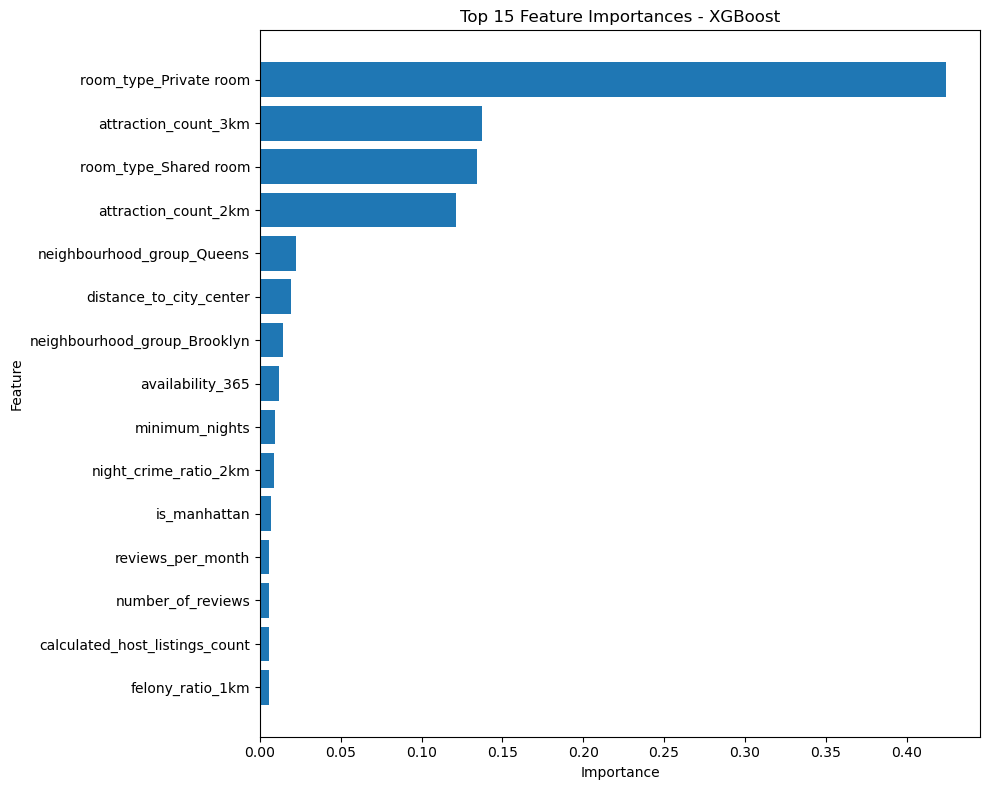

In [14]:
plt.figure(figsize=(10, 8))
top_n = 15

top_importance_df = importance_df.head(top_n).sort_values('importance')

plt.barh(top_importance_df['feature'], top_importance_df['importance'])
plt.title(f'Top {top_n} Feature Importances - XGBoost')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()
